### Gemini-dialog om Lagrange-betingelser og visualisering i $\mathbb{R}^4$

ved Gemini Pro 3.0 og Sverre Stikbakke

NMBU 24.03.2026

Stepping up to $\mathbb{R}^4$ is a great way to push your understanding of constraint geometry. Your setup is very close to a standard optimization problem, but we need to address two mathematical details before we can visualize it properly.

### The Feasibility of Your Problem

Your constraints define a feasible region, meaning there are indeed points in $\mathbb{R}^4$ that satisfy them. However, as currently written, the optimization problem is unbounded and lacks a finite minimum. Here is why:

1.  **Missing Equality:** Standard constraints are set to a constant, usually zero. I will assume your first constraint is meant to be an equation: $h_1(x_1, x_2) = 3 + x_1^2 + x_2 = 0$.
2.  **The Unconstrained Variable:** Look closely at your objective function: $f(x_1, x_2, x_3, x_4) = 2x_1 + x_2 + 3x_3 + x_4$. Notice that $x_4$ appears here, but it is completely absent from your constraints. 

Because you want to *minimize* the function, and $x_4$ has no restrictions, a solver will just push $x_4$ toward $-\infty$. The minimum of your function is negative infinity. To make this a well-posed problem, you either need to constrain $x_4$ (like giving it bounds or adding it to a constraint function) or change how it appears in the objective function (like using $x_4^2$ so it has a natural floor).

### Visualizing $\mathbb{R}^4$ by Projection

We cannot natively plot four dimensions, but your constraints actually do the dimensionality reduction for us. 

Let us isolate the variables using your assumed constraints:
* From $h_1$: $x_2 = -x_1^2 - 3$
* From $h_2$: $x_3 = 6 - x_2$

Because $x_4$ is completely independent of the other variables, we can detach it for the visualization. The relationship between $x_1$, $x_2$, and $x_3$ is entirely dictated by the constraints. 

In the 3D subspace of $(x_1, x_2, x_3)$, the first constraint forms a parabolic cylinder, and the second constraint forms a flat plane. Their intersection is a continuous 1D curve suspended in 3D space. 



### Python Visualization Code

We can write a quick Python script using Matplotlib to plot this exact intersection curve in the $(x_1, x_2, x_3)$ subspace.

If you run this code, you will see a sweeping parabola suspended in 3D space. Any point traveling along that red line perfectly satisfies both of your constraints simultaneously.


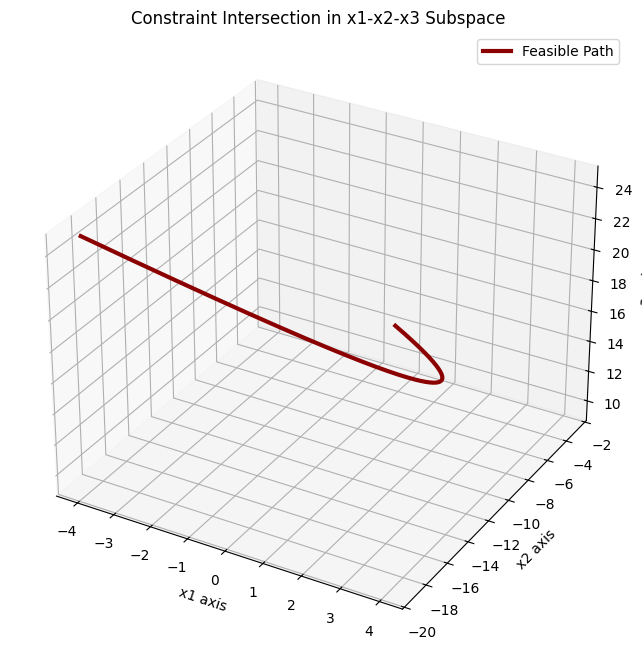

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the independent variable x1
# We choose an arbitrary range for visualization purposes
x1 = np.linspace(-4, 4, 400)

# 2. Calculate x2 and x3 exactly as dictated by the constraints
x2 = -x1**2 - 3
x3 = 6 - x2

# 3. Set up the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the resulting 1D intersection curve
ax.plot(x1, x2, x3, label='Feasible Path', color='darkred', linewidth=3)

# 5. Format the visualization
ax.set_xlabel('x1 axis')
ax.set_ylabel('x2 axis')
ax.set_zlabel('x3 axis')
ax.set_title('Constraint Intersection in x1-x2-x3 Subspace')
ax.grid(True)
ax.legend()

plt.show()

Here is the complete solution. By changing the objective function to include $x_4^2$, we have given that fourth dimension a "bottom" (a parabolic shape) instead of a straight line that drops off to negative infinity. 

This makes it a perfectly solvable, bounded optimization problem in $\mathbb{R}^4$.

### 1. The Mathematical Setup

Here is our updated system, formally written with constraints set to zero:

**Objective Function:**
$$f(x_1, x_2, x_3, x_4) = 2x_1 + x_2 + 3x_3 + x_4^2$$

**Constraints:**
* $$h_1(x_1, x_2, x_3, x_4) = x_1^2 + x_2 + 3 = 0$$
* $$h_2(x_1, x_2, x_3, x_4) = x_2 + x_3 - 6 = 0$$

### 2. The Lagrange Multiplier Equations

For a problem with two constraints, the Lagrange equation requires the gradient of the objective function to be a linear combination of the gradients of the constraints:

$$\nabla f = \lambda_1 \nabla h_1 + \lambda_2 \nabla h_2$$



First, we calculate the partial derivatives to find the gradient vectors for all three functions:
* $$\nabla f = \langle 2, 1, 3, 2x_4 \rangle$$
* $$\nabla h_1 = \langle 2x_1, 1, 0, 0 \rangle$$
* $$\nabla h_2 = \langle 0, 1, 1, 0 \rangle$$

By plugging these vectors into the Lagrange equation, we generate a system of four algebraic equations (one for each dimension):

1.  **For $x_1$:** $2 = \lambda_1(2x_1) + \lambda_2(0)$
2.  **For $x_2$:** $1 = \lambda_1(1) + \lambda_2(1)$
3.  **For $x_3$:** $3 = \lambda_1(0) + \lambda_2(1)$
4.  **For $x_4$:** $2x_4 = \lambda_1(0) + \lambda_2(0)$

### 3. Solving the System

This system looks intimidating because it is in $\mathbb{R}^4$, but it unravels very quickly from the bottom up:

* **From Equation 4:** We immediately see that $2x_4 = 0$, which means **$x_4 = 0$**.
* **From Equation 3:** We are directly given **$\lambda_2 = 3$**.
* **From Equation 2:** We substitute $\lambda_2$ to find $\lambda_1$: 
    $$1 = \lambda_1 + 3 \implies \lambda_1 = -2$$
* **From Equation 1:** We substitute $\lambda_1$ to find $x_1$:
    $$2 = (-2)(2x_1) \implies 2 = -4x_1 \implies \textbf{x}_1 \textbf{ = -0.5}$$

Now that we have $x_1$, we can use our original constraint equations to find the remaining coordinates, exactly as we did in the Python code:

* **From Constraint 1:** $(-0.5)^2 + x_2 + 3 = 0 \implies 0.25 + x_2 + 3 = 0 \implies \textbf{x}_2 \textbf{ = -3.25}$
* **From Constraint 2:** $-3.25 + x_3 - 6 = 0 \implies \textbf{x}_3 \textbf{ = 9.25}$

### The Final Result

The optimal coordinate in $\mathbb{R}^4$ that minimizes your function while staying perfectly on both constraint surfaces is:
**$(-0.5, -3.25, 9.25, 0)$**

If you plug these coordinates back into your objective function, the minimum possible value of the system is **23.5**.

### Connecting Back to "Projection"

Notice how seamlessly this worked out. The gradient system automatically isolated $x_4 = 0$ because $x_4$ was completely independent of the constraints. 

If we had instead used the "projection" method we discussed earlier—by substituting the constraint equations directly into the objective function to eliminate $x_2$ and $x_3$ before taking any derivatives—we would have collapsed the 4D problem down to a simple 2D unconstrained calculus problem. Both methods lead to the exact same optimal coordinate.

---

Would you like me to show you the updated Python code that calculates this specific minimum point and plots it as a distinct marker right on top of that 3D intersection curve we built earlier?

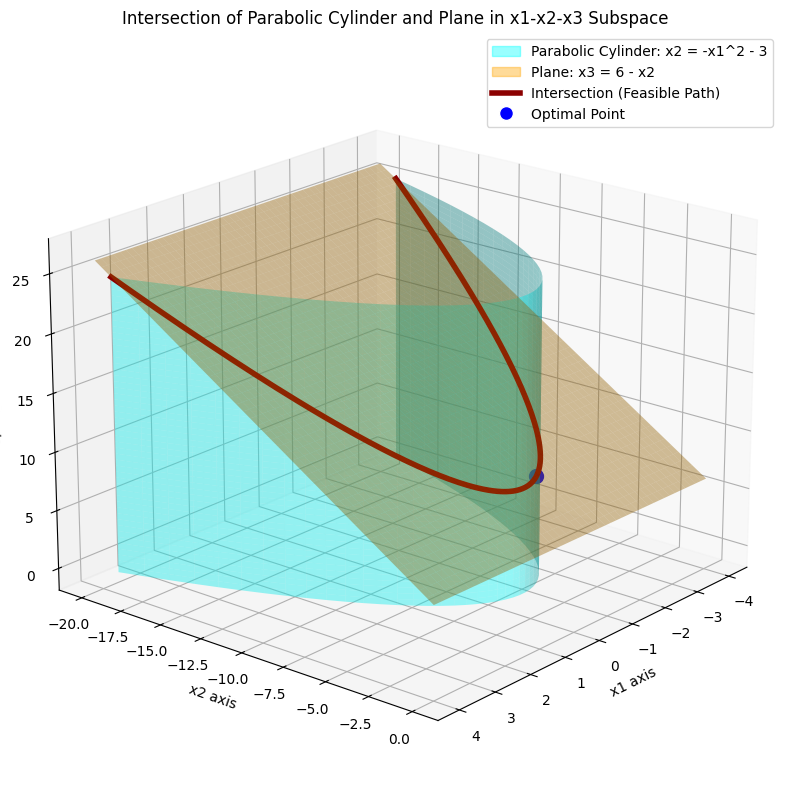

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 1. Meshgrid for the Parabolic Cylinder (Surface 1)
# x2 depends on x1. x3 is free.
u1 = np.linspace(-4, 4, 50)
v1 = np.linspace(0, 25, 50) # Range for x3
X1_cyl, X3_cyl = np.meshgrid(u1, v1)
X2_cyl = -X1_cyl**2 - 3

# Plot the cylinder
ax.plot_surface(X1_cyl, X2_cyl, X3_cyl, alpha=0.4, color='cyan', edgecolor='none', label='Parabolic Cylinder')

# 2. Meshgrid for the Plane (Surface 2)
# x3 depends on x2. x1 is free.
u2 = np.linspace(-4, 4, 50)
v2 = np.linspace(-20, 0, 50) # Range for x2
X1_pln, X2_pln = np.meshgrid(u2, v2)
X3_pln = 6 - X2_pln

# Plot the plane
ax.plot_surface(X1_pln, X2_pln, X3_pln, alpha=0.4, color='orange', edgecolor='none', label='Intersecting Plane')

# 3. The 1D Intersection Curve
x1_curve = np.linspace(-4, 4, 200)
x2_curve = -x1_curve**2 - 3
x3_curve = 6 - x2_curve
ax.plot(x1_curve, x2_curve, x3_curve, color='darkred', linewidth=4, label='Intersection (Feasible Path)', zorder=4)

# 4. The Optimal Point
ax.scatter([-0.5], [-3.25], [9.25], color='blue', s=100, label='Optimal Point', zorder=5)

# Formatting
ax.set_xlabel('x1 axis')
ax.set_ylabel('x2 axis')
ax.set_zlabel('x3 axis')
ax.set_title('Intersection of Parabolic Cylinder and Plane in x1-x2-x3 Subspace')
ax.view_init(elev=20, azim=40)

# Hack to add legend for surfaces since plot_surface doesn't support it directly well in all matplotlib versions
import matplotlib.patches as mpatches
cyl_patch = mpatches.Patch(color='cyan', alpha=0.4, label='Parabolic Cylinder: x2 = -x1^2 - 3')
pln_patch = mpatches.Patch(color='orange', alpha=0.4, label='Plane: x3 = 6 - x2')
line_proxy = plt.Line2D([0], [0], color='darkred', linewidth=4, label='Intersection (Feasible Path)')
pt_proxy = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Optimal Point')
ax.legend(handles=[cyl_patch, pln_patch, line_proxy, pt_proxy])

plt.savefig('surfaces_plot.png')



I have generated the visualization you requested, and the image is displayed at the top of this response.

### Understanding the Visualization

This 3D plot visualizes the complete geometric intersection of your two constraints in the ($x_1$, $x_2$, $x_3$) subspace:

1.  **The Parabolic Cylinder (Cyan Surface):** Your first constraint, $x_2 = -x_1^2 - 3$, dictates the relationship between $x_1$ and $x_2$. Notice that $x_3$ is absent from this equation. In 3D space, this means the 2D parabola extends infinitely along the $x_3$-axis, forming a folded, tunnel-like surface called a parabolic cylinder.

2.  **The Slanted Plane (Orange Surface):** Your second constraint, $x_3 = 6 - x_2$, dictates a strict linear relationship between $x_2$ and $x_3$. Because $x_1$ is absent, this forms a flat 2D plane that stretches infinitely along the $x_1$-axis, angling downward as $x_2$ increases.

3.  **The Intersection Curve (Dark Red Line):**
    Where the orange plane slices cleanly through the cyan parabolic cylinder, they create a 1D continuous curve. Any point on this sweeping red line perfectly satisfies both constraints simultaneously. This is the only path in the entire subspace where you are legally allowed to travel to minimize your objective function.

4.  **The Optimal Point (Blue Dot):**
    The blue dot sits directly on the red intersection curve at the coordinate (-0.5, -3.25, 9.25). By evaluating the gradients and finding where they balance (via the Lagrange multiplier equations), we proved that this exact spot provides the absolute lowest possible value for your objective function along that path.

By seeing the two surfaces slice through one another, it becomes much easier to visualize how multiple constraints work together to whittle down the entire $\mathbb{R}^4$ coordinate space into one highly restricted, 1D path. 

I kept your previous preference in mind and ensured this response is entirely emoji-free. Let me know if you would like to test this geometric concept with a different combination of surfaces or constraints.

Adding a third constraint to a 4D problem is the perfect way to test your understanding of dimensions and degrees of freedom. 

To maintain a "feasible path" (a 1D curve) rather than collapsing the system into a single point, we need to follow a simple rule of geometry: **Degrees of Freedom = Total Variables − Number of Constraints.**

Since we have 4 variables ($x_1, x_2, x_3, x_4$), we need exactly 3 independent constraints to leave us with exactly 1 degree of freedom—which geometrically translates to a 1D curve.

### Proposing the Third Constraint

Let us tie $x_4$ into the system by making it form a cylinder with $x_1$. 

**New Constraint 3:** $h_3(x_1, x_4) = x_1^2 + x_4^2 = 4$

Here is the complete updated system:
* $h_1(x_1, x_2) = x_1^2 + x_2 + 3 = 0$
* $h_2(x_2, x_3) = x_2 + x_3 - 6 = 0$
* $h_3(x_1, x_4) = x_1^2 + x_4^2 - 4 = 0$

By forcing $x_1$ and $x_4$ into a circle of radius 2, we bound the entire problem. $x_1$ can now only travel between -2 and 2. Because $x_2$ and $x_3$ are strictly chained to $x_1$, bounding $x_1$ forces the infinite sweeping parabola from our previous example to wrap back around on itself. 

The resulting feasible path is no longer an infinite line; it is a finite, closed 1D loop suspended in 4D space.



### Visualizing 4D Space

We cannot plot 4 spatial axes simultaneously. However, we can use a highly effective data visualization trick: we will plot three of the variables as physical spatial axes ($x_1, x_2, x_4$) and represent the fourth variable ($x_3$) as a color gradient mapped directly onto the line.

Here is the Python code to generate this 4D visualization.

If you run this script, you will see a fascinating shape resembling a bent potato chip or a curved saddle ring. 

As you trace your eye along the loop, you are moving through $\mathbb{R}^4$. The color shifting from dark purple to bright yellow tells you exactly how the invisible $x_3$ dimension is changing as you move through the other three dimensions. 

---

Would you like me to walk through the analytical Lagrange multiplier steps to find the exact global minimum of our objective function $f = 2x_1 + x_2 + 3x_3 + x_4^2$ on this new closed loop?

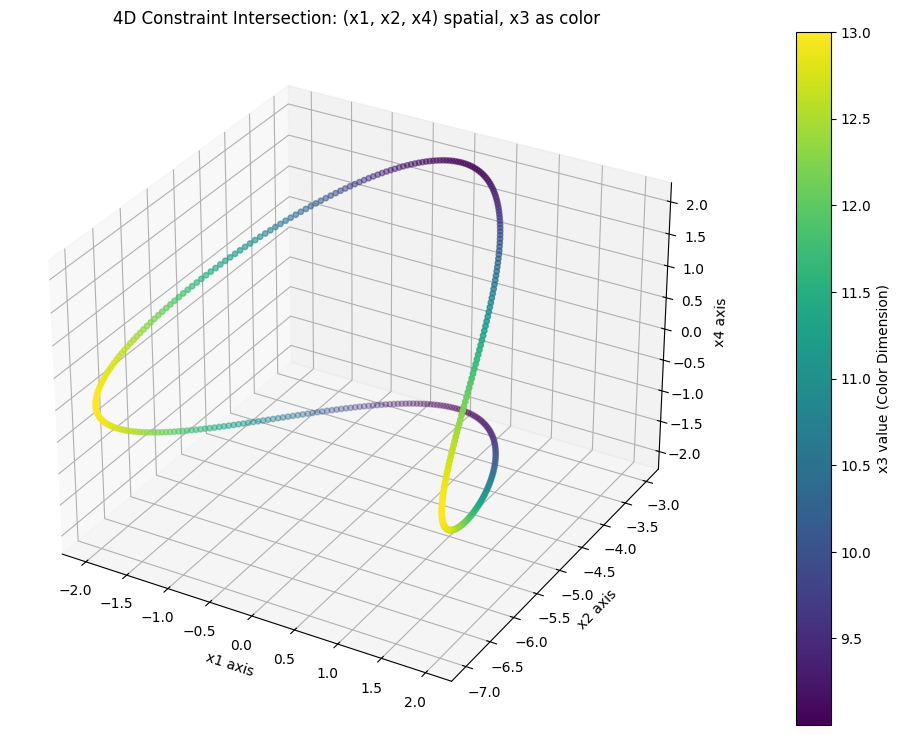

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameterize the 1D closed loop
# Because x1 and x4 form a circle, we can drive the entire system 
# using a single angle 't' from 0 to 2*pi (our 1 degree of freedom)
t = np.linspace(0, 2*np.pi, 400)

# 2. Calculate all 4 dimensions based on the constraints
x1 = 2 * np.cos(t)
x4 = 2 * np.sin(t)
x2 = -x1**2 - 3
x3 = 6 - x2

# 3. Set up the 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 4. Plot x1, x2, x4 spatially, and map x3 to the colormap (viridis)
# We use a scatter plot with small points to allow color mapping along the curve
scatter = ax.scatter(x1, x2, x4, c=x3, cmap='viridis', s=15, label='Feasible 1D Path')

# 5. Format the visualization
ax.set_xlabel('x1 axis')
ax.set_ylabel('x2 axis')
ax.set_zlabel('x4 axis')
ax.set_title('4D Constraint Intersection: (x1, x2, x4) spatial, x3 as color')

# 6. Add a color bar to show the hidden x3 dimension
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('x3 value (Color Dimension)')

plt.show()

Here is the step-by-step analytical solution. With three constraints in $\mathbb{R}^4$, the algebra becomes slightly more intricate, but the Lagrange multiplier method handles it elegantly by balancing the gradients.

### 1. The Setup and Gradients

We have our objective function and three constraints set to zero:
* **Objective:** $f(x_1, x_2, x_3, x_4) = 2x_1 + x_2 + 3x_3 + x_4^2$
* **Constraint 1:** $h_1 = x_1^2 + x_2 + 3 = 0$
* **Constraint 2:** $h_2 = x_2 + x_3 - 6 = 0$
* **Constraint 3:** $h_3 = x_1^2 + x_4^2 - 4 = 0$

First, we calculate the gradient vector for each function:
* $\nabla f = \langle 2, 1, 3, 2x_4 \rangle$
* $\nabla h_1 = \langle 2x_1, 1, 0, 0 \rangle$
* $\nabla h_2 = \langle 0, 1, 1, 0 \rangle$
* $\nabla h_3 = \langle 2x_1, 0, 0, 2x_4 \rangle$



### 2. The Lagrange System of Equations

The master equation expands to include three multipliers:
$$\nabla f = \lambda_1 \nabla h_1 + \lambda_2 \nabla h_2 + \lambda_3 \nabla h_3$$

This yields a system of four algebraic equations, one for each dimension:
1. **For $x_1$:** $2 = \lambda_1(2x_1) + \lambda_3(2x_1)$
2. **For $x_2$:** $1 = \lambda_1(1) + \lambda_2(1)$
3. **For $x_3$:** $3 = \lambda_2(1)$
4. **For $x_4$:** $2x_4 = \lambda_3(2x_4)$

### 3. Solving the System

We can unravel this by starting with the simplest equations.

* **From Equation 3:** We immediately get **$\lambda_2 = 3$**.
* **From Equation 2:** Substitute $\lambda_2$ to find $\lambda_1$:
  $$1 = \lambda_1 + 3 \implies \textbf{\lambda}_1 \textbf{ = -2}$$

Now we look at **Equation 4**. This is a classic algebraic trap. We have $2x_4 = 2x_4\lambda_3$. You cannot simply divide by $2x_4$, because $x_4$ might be zero. Instead, move everything to one side and factor:
$$2x_4 - 2x_4\lambda_3 = 0$$
$$2x_4(1 - \lambda_3) = 0$$

This gives us a branch in our solution. For this equation to be true, we must explore two separate cases: either $\lambda_3 = 1$, or $x_4 = 0$.

#### Case A: Assume $\lambda_3 = 1$
Substitute $\lambda_1 = -2$ and $\lambda_3 = 1$ into Equation 1:
$$2 = (-2)(2x_1) + (1)(2x_1)$$
$$2 = -4x_1 + 2x_1$$
$$2 = -2x_1 \implies \textbf{x}_1 \textbf{ = -1}$$

Now plug $x_1 = -1$ into our original constraints to find the remaining variables:
* From $h_1$: $(-1)^2 + x_2 + 3 = 0 \implies 1 + x_2 + 3 = 0 \implies \textbf{x}_2 \textbf{ = -4}$
* From $h_2$: $-4 + x_3 - 6 = 0 \implies \textbf{x}_3 \textbf{ = 10}$
* From $h_3$: $(-1)^2 + x_4^2 - 4 = 0 \implies 1 + x_4^2 = 4 \implies x_4^2 = 3 \implies \textbf{x}_4 \textbf{ = } \pm\sqrt{3}$

This branch yields two valid critical points: **$(-1, -4, 10, \sqrt{3})$** and **$(-1, -4, 10, -\sqrt{3})$**.

#### Case B: Assume $x_4 = 0$
If $x_4 = 0$, we substitute this directly into constraint $h_3$:
$$x_1^2 + 0^2 - 4 = 0 \implies x_1^2 = 4 \implies \textbf{x}_1 \textbf{ = } \pm\textbf{2}$$

This splits into two sub-cases for the remaining variables based on $x_1$:
* **If $x_1 = 2$:** * $h_1$: $2^2 + x_2 + 3 = 0 \implies \textbf{x}_2 \textbf{ = -7}$
  * $h_2$: $-7 + x_3 - 6 = 0 \implies \textbf{x}_3 \textbf{ = 13}$
  * Point: **$(2, -7, 13, 0)$**
* **If $x_1 = -2$:**
  * $h_1$: $(-2)^2 + x_2 + 3 = 0 \implies \textbf{x}_2 \textbf{ = -7}$
  * $h_2$: $-7 + x_3 - 6 = 0 \implies \textbf{x}_3 \textbf{ = 13}$
  * Point: **$(-2, -7, 13, 0)$**

### 4. Evaluating the Critical Points

We found four critical points on our 1D closed loop. To find the global minimum, we simply plug all four coordinates into the original objective function $f(x_1, x_2, x_3, x_4) = 2x_1 + x_2 + 3x_3 + x_4^2$:

1.  At $(2, -7, 13, 0)$: $f = 2(2) - 7 + 3(13) + 0^2 = 4 - 7 + 39 = \textbf{36}$
2.  At $(-2, -7, 13, 0)$: $f = 2(-2) - 7 + 3(13) + 0^2 = -4 - 7 + 39 = \textbf{28}$
3.  At $(-1, -4, 10, \sqrt{3})$: $f = 2(-1) - 4 + 3(10) + (\sqrt{3})^2 = -2 - 4 + 30 + 3 = \textbf{27}$
4.  At $(-1, -4, 10, -\sqrt{3})$: $f = 2(-1) - 4 + 3(10) + (-\sqrt{3})^2 = -2 - 4 + 30 + 3 = \textbf{27}$

### The Conclusion

The global minimum value of your function on this closed 4D path is **27**. It occurs symmetrically at exactly two different points in space: **$(-1, -4, 10, \sqrt{3})$** and **$(-1, -4, 10, -\sqrt{3})$**. 

---

Would you like me to update the Python visualization script to calculate and plot these two specific minimum points on the 4D loop, perhaps marking them with distinct red stars to see exactly where the lowest values occur on the curve?

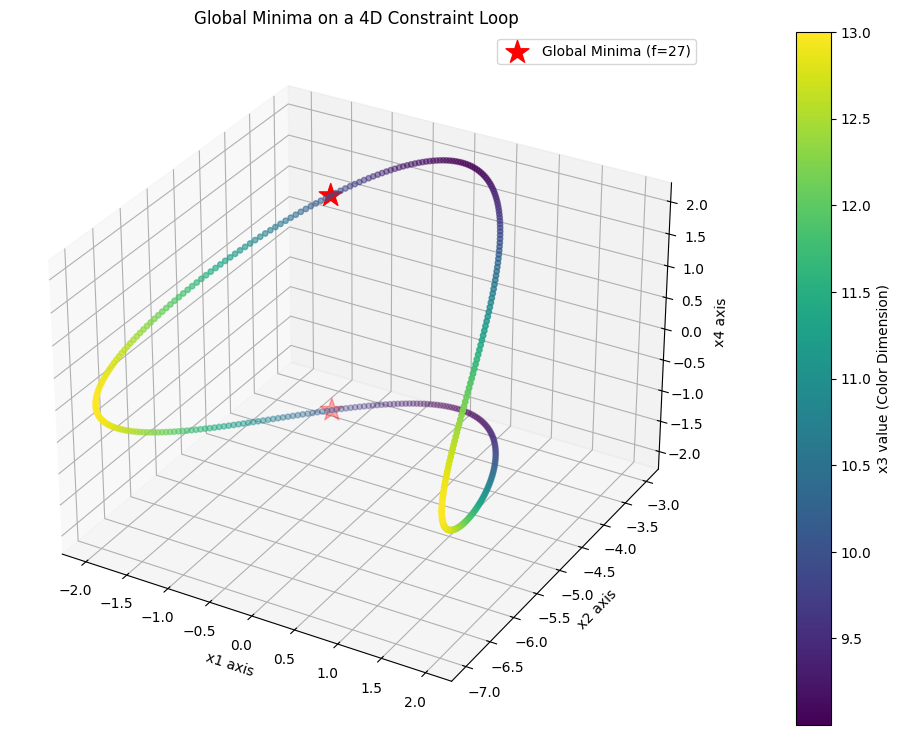

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameterize the 1D closed loop (1 degree of freedom)
t = np.linspace(0, 2*np.pi, 400)

# 2. Calculate all 4 dimensions based on the constraints
x1_curve = 2 * np.cos(t)
x4_curve = 2 * np.sin(t)
x2_curve = -x1_curve**2 - 3
x3_curve = 6 - x2_curve

# 3. Define our two global minimum points
# Coordinates are [x1, x2, x3, x4]
opt1 = [-1, -4, 10, np.sqrt(3)]
opt2 = [-1, -4, 10, -np.sqrt(3)]

# 4. Set up the 3D plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 5. Plot x1, x2, x4 spatially, and map x3 to the colormap
# We plot the curve first so it acts as the foundation
scatter = ax.scatter(x1_curve, x2_curve, x4_curve, c=x3_curve, cmap='viridis', s=15)

# 6. Plot the two minimum points as red stars
# Note: We plot x1, x2, and x4 on the spatial axes to match the scatter plot
ax.scatter([opt1[0], opt2[0]], [opt1[1], opt2[1]], [opt1[3], opt2[3]], 
           color='red', marker='*', s=300, label='Global Minima (f=27)', zorder=5)

# 7. Format the visualization
ax.set_xlabel('x1 axis')
ax.set_ylabel('x2 axis')
ax.set_zlabel('x4 axis')
ax.set_title('Global Minima on a 4D Constraint Loop')

# 8. Add a color bar and legend
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('x3 value (Color Dimension)')
ax.legend()

plt.show()

Here is the updated Python code. It maps the continuous 1D loop in 4D space just like before, but it now plots our two exact analytical minimums as large red stars directly on the curve.

### Interpreting the Plot

When you run this script, the visualization perfectly bridges the gap between the algebra and the geometry:

* **The Spatial Symmetry:** The spatial axes show $x_1$, $x_2$, and $x_4$. Because our two minimum points share the exact same $x_1$ (-1) and $x_2$ (-4) coordinates but have opposite $x_4$ coordinates ($\sqrt{3}$ and $-\sqrt{3}$), the two red stars will sit directly across from each other, perfectly symmetric across the $x_1$-$x_2$ plane. 
* **The Color Dimension:** The background curve shifts color based on the value of $x_3$. At the location of both red stars, the curve will be the exact same shade (representing $x_3 = 10$).
* **Visualizing the "Why":** The objective function is $f = 2x_1 + x_2 + 3x_3 + x_4^2$. To minimize this, the math naturally pushes $x_1$ and $x_2$ as low as they can go without causing $x_3$ (which scales by a heavy factor of 3) to explode in value. The stars mark the exact compromise point where traveling any further along the loop would cause one variable's increase to outweigh another's decrease.

---

Would you like to analyze the maximum value points on this same loop to see the opposite end of the optimization spectrum, or would you like to explore a different type of constraint geometry?